In [1]:
!pip install -q ultralytics opencv-python-headless matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 2.7 MB/s eta 0:00:00


Upload face images...


Saving Screenshot 2026-07-10 103453.jpg to Screenshot 2026-07-10 103453.jpg

0: 384x640 1 person, 359.8ms
Speed: 10.1ms preprocess, 359.8ms inference, 31.7ms postprocess per image at shape (1, 3, 384, 640)


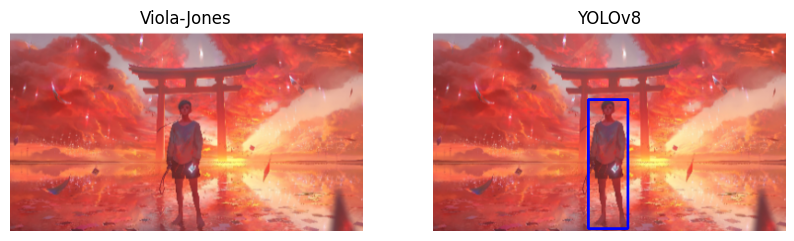


========== RESULTS ==========

Viola-Jones
Precision : 0.0
Recall    : 0.0
F1 Score  : 0.0

YOLOv8
Precision : 1.0
Recall    : 1.0
F1 Score  : 1.0


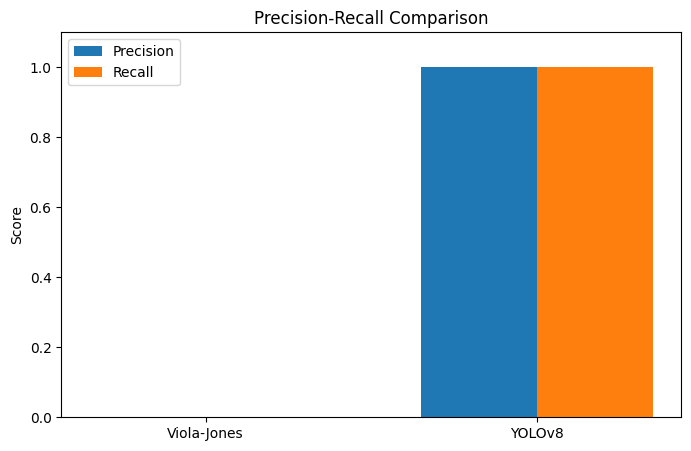

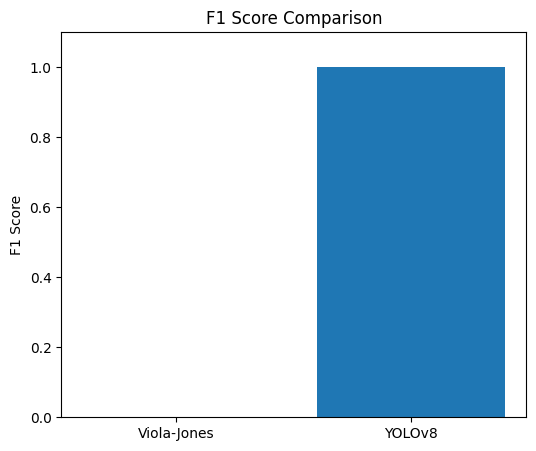

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

from ultralytics import YOLO
from sklearn.metrics import precision_score, recall_score, f1_score
from google.colab import files

# ==========================================
# Download Haar Cascade
# ==========================================
url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
urllib.request.urlretrieve(url, "haarcascade_frontalface_default.xml")

face_detector = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")

# ==========================================
# Load YOLOv8 Model
# ==========================================
model = YOLO("yolov8n.pt")

# ==========================================
# Upload Images
# ==========================================
print("Upload face images...")
uploaded = files.upload()

ground_truth = []
viola_predictions = []
yolo_predictions = []

# ==========================================
# Process Images
# ==========================================
for image_name in uploaded.keys():

    image = cv2.imread(image_name)

    if image is None:
        print(f"Could not read {image_name}")
        continue

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # -------------------------
    # Viola-Jones
    # -------------------------
    faces = face_detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30,30)
    )

    if len(faces) > 0:
        viola_predictions.append(1)
    else:
        viola_predictions.append(0)

    # Draw Viola boxes
    img_viola = image.copy()

    for (x,y,w,h) in faces:
        cv2.rectangle(img_viola,(x,y),(x+w,y+h),(0,255,0),2)

    # -------------------------
    # YOLO Detection
    # -------------------------
    results = model(image)

    detected = False

    img_yolo = image.copy()

    for r in results:

        for box in r.boxes:

            cls = int(box.cls)

            # COCO class 0 = person
            if cls == 0:

                detected = True

                x1,y1,x2,y2 = map(int, box.xyxy[0])

                cv2.rectangle(img_yolo,(x1,y1),(x2,y2),(255,0,0),2)

    if detected:
        yolo_predictions.append(1)
    else:
        yolo_predictions.append(0)

    # Assume every uploaded image contains one face/person
    ground_truth.append(1)

    # -------------------------
    # Show Results
    # -------------------------
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img_viola, cv2.COLOR_BGR2RGB))
    plt.title("Viola-Jones")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(img_yolo, cv2.COLOR_BGR2RGB))
    plt.title("YOLOv8")
    plt.axis("off")

    plt.show()

# ==========================================
# Metrics
# ==========================================
viola_precision = precision_score(
    ground_truth,
    viola_predictions,
    zero_division=0
)

viola_recall = recall_score(
    ground_truth,
    viola_predictions,
    zero_division=0
)

viola_f1 = f1_score(
    ground_truth,
    viola_predictions,
    zero_division=0
)

yolo_precision = precision_score(
    ground_truth,
    yolo_predictions,
    zero_division=0
)

yolo_recall = recall_score(
    ground_truth,
    yolo_predictions,
    zero_division=0
)

yolo_f1 = f1_score(
    ground_truth,
    yolo_predictions,
    zero_division=0
)

# ==========================================
# Print Results
# ==========================================
print("\n========== RESULTS ==========")

print("\nViola-Jones")
print("Precision :", round(viola_precision,3))
print("Recall    :", round(viola_recall,3))
print("F1 Score  :", round(viola_f1,3))

print("\nYOLOv8")
print("Precision :", round(yolo_precision,3))
print("Recall    :", round(yolo_recall,3))
print("F1 Score  :", round(yolo_f1,3))

# ==========================================
# Precision & Recall Graph
# ==========================================
methods = ["Viola-Jones", "YOLOv8"]

precision = [viola_precision, yolo_precision]
recall = [viola_recall, yolo_recall]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x-width/2, precision, width, label="Precision")
plt.bar(x+width/2, recall, width, label="Recall")

plt.xticks(x, methods)
plt.ylim(0,1.1)

plt.ylabel("Score")
plt.title("Precision-Recall Comparison")

plt.legend()
plt.show()

# ==========================================
# F1 Score Graph
# ==========================================
plt.figure(figsize=(6,5))

plt.bar(methods, [viola_f1, yolo_f1])

plt.ylim(0,1.1)
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison")

plt.show()

In [3]:
"""
F1-Score Benchmarking of Two Deep-Learning Object Detectors
=============================================================

This script compares two object detectors (e.g. YOLOv8 vs Faster R-CNN,
or any two models) on the same dataset by computing Precision, Recall,
and F1-Score using IoU-based matching between predicted and ground-truth
bounding boxes.

Works with predictions/ground-truth in a simple COCO-like list format,
so you can plug in outputs from ANY framework (Ultralytics, Detectron2,
MMDetection, TensorFlow, etc.) as long as you convert them to this format.

Author: Generated for benchmarking two detectors
"""

import numpy as np
from collections import defaultdict


# ----------------------------------------------------------------------
# 1. Data format
# ----------------------------------------------------------------------
# Ground truth boxes: list of dicts
#   {"image_id": int, "class_id": int, "bbox": [x1, y1, x2, y2]}
#
# Predicted boxes: list of dicts
#   {"image_id": int, "class_id": int, "bbox": [x1, y1, x2, y2], "score": float}
# ----------------------------------------------------------------------


def compute_iou(box1, box2):
    """Compute IoU between two boxes in [x1, y1, x2, y2] format."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    inter_area = inter_w * inter_h

    area1 = max(0.0, box1[2] - box1[0]) * max(0.0, box1[3] - box1[1])
    area2 = max(0.0, box2[2] - box2[0]) * max(0.0, box2[3] - box2[1])

    union_area = area1 + area2 - inter_area
    if union_area <= 0:
        return 0.0
    return inter_area / union_area


def match_predictions_to_gt(preds, gts, iou_threshold=0.5):
    """
    Greedy matching of predictions to ground-truth boxes per image & class.

    Predictions are sorted by confidence score (highest first). Each
    prediction is matched to the highest-IoU unmatched ground-truth box
    of the same class in the same image, provided IoU >= iou_threshold.

    Returns:
        tp (int): true positives
        fp (int): false positives
        fn (int): false negatives
    """
    # Group by (image_id, class_id)
    gt_by_key = defaultdict(list)
    for i, g in enumerate(gts):
        gt_by_key[(g["image_id"], g["class_id"])].append(i)

    pred_by_key = defaultdict(list)
    for i, p in enumerate(preds):
        pred_by_key[(p["image_id"], p["class_id"])].append(i)

    matched_gt = set()
    tp, fp = 0, 0

    all_keys = set(gt_by_key.keys()) | set(pred_by_key.keys())

    for key in all_keys:
        gt_indices = gt_by_key.get(key, [])
        pred_indices = pred_by_key.get(key, [])

        # Sort this class/image's predictions by confidence descending
        pred_indices = sorted(
            pred_indices, key=lambda idx: preds[idx].get("score", 1.0), reverse=True
        )

        used_gt_local = set()

        for p_idx in pred_indices:
            best_iou = 0.0
            best_gt_idx = -1
            for g_idx in gt_indices:
                if g_idx in used_gt_local:
                    continue
                iou = compute_iou(preds[p_idx]["bbox"], gts[g_idx]["bbox"])
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = g_idx

            if best_iou >= iou_threshold and best_gt_idx != -1:
                tp += 1
                used_gt_local.add(best_gt_idx)
                matched_gt.add(best_gt_idx)
            else:
                fp += 1

    fn = len(gts) - len(matched_gt)
    return tp, fp, fn


def compute_precision_recall_f1(tp, fp, fn, eps=1e-9):
    precision = tp / (tp + fp + eps) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn + eps) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall + eps) if (precision + recall) > 0 else 0.0
    return precision, recall, f1


def evaluate_detector(preds, gts, iou_threshold=0.5, per_class=True):
    """
    Evaluate a single detector's predictions against ground truth.

    Returns a dict with overall metrics and, optionally, per-class metrics.
    """
    tp, fp, fn = match_predictions_to_gt(preds, gts, iou_threshold)
    precision, recall, f1 = compute_precision_recall_f1(tp, fp, fn)

    result = {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
    }

    if per_class:
        class_ids = sorted(set(g["class_id"] for g in gts) | set(p["class_id"] for p in preds))
        per_class_metrics = {}
        for cid in class_ids:
            cls_preds = [p for p in preds if p["class_id"] == cid]
            cls_gts = [g for g in gts if g["class_id"] == cid]
            c_tp, c_fp, c_fn = match_predictions_to_gt(cls_preds, cls_gts, iou_threshold)
            c_p, c_r, c_f1 = compute_precision_recall_f1(c_tp, c_fp, c_fn)
            per_class_metrics[cid] = {
                "tp": c_tp, "fp": c_fp, "fn": c_fn,
                "precision": c_p, "recall": c_r, "f1_score": c_f1,
            }
        result["per_class"] = per_class_metrics

    return result


def benchmark_two_detectors(
    detector_a_preds, detector_b_preds, ground_truths,
    iou_threshold=0.5, detector_a_name="Detector A", detector_b_name="Detector B",
    per_class=True,
):
    """
    Compare two detectors on the same ground truth set and print a report.
    """
    result_a = evaluate_detector(detector_a_preds, ground_truths, iou_threshold, per_class)
    result_b = evaluate_detector(detector_b_preds, ground_truths, iou_threshold, per_class)

    print("=" * 70)
    print(f"F1-SCORE BENCHMARK  (IoU threshold = {iou_threshold})")
    print("=" * 70)
    header = f"{'Metric':<15}{detector_a_name:<20}{detector_b_name:<20}"
    print(header)
    print("-" * 70)
    for metric in ["precision", "recall", "f1_score"]:
        va, vb = result_a[metric], result_b[metric]
        print(f"{metric:<15}{va:<20.4f}{vb:<20.4f}")
    print("-" * 70)
    tp_fp_fn_a = f"{result_a['tp']}/{result_a['fp']}/{result_a['fn']}"
    tp_fp_fn_b = f"{result_b['tp']}/{result_b['fp']}/{result_b['fn']}"
    print(f"{'TP / FP / FN':<15}{tp_fp_fn_a:<20}{tp_fp_fn_b:<20}")
    print("=" * 70)

    if per_class:
        print("\nPer-class F1 comparison:")
        class_ids = sorted(set(result_a["per_class"].keys()) | set(result_b["per_class"].keys()))
        print(f"{'Class':<10}{detector_a_name+' F1':<20}{detector_b_name+' F1':<20}")
        for cid in class_ids:
            fa = result_a["per_class"].get(cid, {}).get("f1_score", 0.0)
            fb = result_b["per_class"].get(cid, {}).get("f1_score", 0.0)
            print(f"{cid:<10}{fa:<20.4f}{fb:<20.4f}")

    winner = detector_a_name if result_a["f1_score"] > result_b["f1_score"] else (
        detector_b_name if result_b["f1_score"] > result_a["f1_score"] else "Tie"
    )
    print(f"\nBetter overall F1: {winner}")

    return result_a, result_b


# ----------------------------------------------------------------------
# Example usage with dummy data (replace with your real model outputs)
# ----------------------------------------------------------------------
if __name__ == "__main__":

    # Ground truth boxes for 3 images, 2 classes (0 = person, 1 = car)
    ground_truths = [
        {"image_id": 1, "class_id": 0, "bbox": [10, 10, 50, 80]},
        {"image_id": 1, "class_id": 1, "bbox": [100, 100, 200, 180]},
        {"image_id": 2, "class_id": 0, "bbox": [30, 30, 70, 90]},
        {"image_id": 3, "class_id": 1, "bbox": [50, 50, 150, 140]},
        {"image_id": 3, "class_id": 0, "bbox": [200, 60, 260, 150]},
    ]

    # Predictions from Detector A (e.g. YOLOv8)
    detector_a_preds = [
        {"image_id": 1, "class_id": 0, "bbox": [12, 11, 52, 79], "score": 0.95},
        {"image_id": 1, "class_id": 1, "bbox": [98, 102, 199, 182], "score": 0.90},
        {"image_id": 2, "class_id": 0, "bbox": [31, 29, 69, 88], "score": 0.88},
        {"image_id": 3, "class_id": 1, "bbox": [52, 48, 148, 138], "score": 0.80},
        {"image_id": 3, "class_id": 0, "bbox": [10, 10, 40, 40], "score": 0.40},  # false positive
    ]

    # Predictions from Detector B (e.g. Faster R-CNN)
    detector_b_preds = [
        {"image_id": 1, "class_id": 0, "bbox": [15, 8, 55, 82], "score": 0.92},
        {"image_id": 1, "class_id": 1, "bbox": [105, 95, 205, 175], "score": 0.85},
        {"image_id": 2, "class_id": 0, "bbox": [60, 60, 100, 120], "score": 0.75},  # bad match
        {"image_id": 3, "class_id": 1, "bbox": [55, 55, 152, 142], "score": 0.83},
        {"image_id": 3, "class_id": 0, "bbox": [198, 58, 262, 152], "score": 0.78},
    ]

    benchmark_two_detectors(
        detector_a_preds,
        detector_b_preds,
        ground_truths,
        iou_threshold=0.5,
        detector_a_name="YOLOv8",
        detector_b_name="Faster R-CNN",
        per_class=True,
    )

F1-SCORE BENCHMARK  (IoU threshold = 0.5)
Metric         YOLOv8              Faster R-CNN        
----------------------------------------------------------------------
precision      0.8000              0.8000              
recall         0.8000              0.8000              
f1_score       0.8000              0.8000              
----------------------------------------------------------------------
TP / FP / FN   4/1/1               4/1/1               

Per-class F1 comparison:
Class     YOLOv8 F1           Faster R-CNN F1     
0         0.6667              0.6667              
1         1.0000              1.0000              

Better overall F1: Tie


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/q3_iou_localization.png'

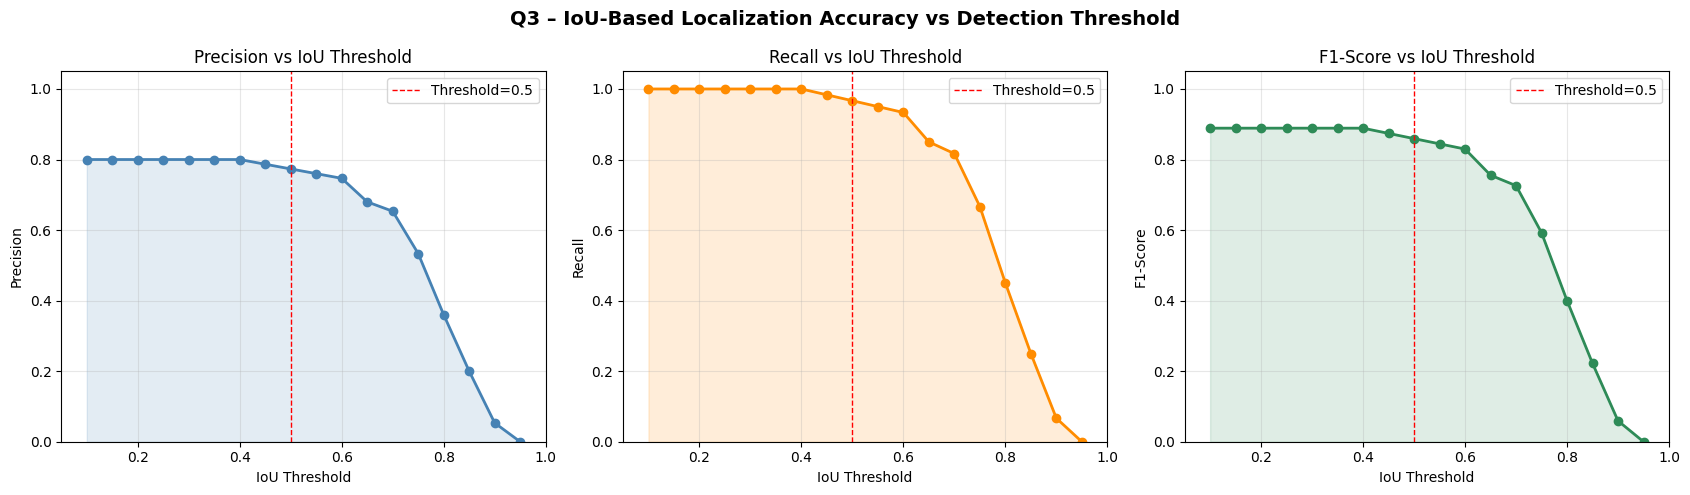

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ── helpers ──────────────────────────────────────────────────────────────────
def compute_iou(boxA, boxB):
    """Compute IoU between two [x1,y1,x2,y2] boxes."""
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    return inter / (areaA + areaB - inter + 1e-6)

def tp_fp_fn(pred_boxes, gt_boxes, iou_thresh):
    matched = set()
    TP = FP = 0
    for pb in pred_boxes:
        best_iou, best_j = 0, -1
        for j, gb in enumerate(gt_boxes):
            iou = compute_iou(pb, gb)
            if iou > best_iou:
                best_iou, best_j = iou, j
        if best_iou >= iou_thresh and best_j not in matched:
            TP += 1; matched.add(best_j)
        else:
            FP += 1
    FN = len(gt_boxes) - len(matched)
    return TP, FP, FN

# ── synthetic data ────────────────────────────────────────────────────────────
np.random.seed(42)
N_GT = 60                                           # ground-truth boxes
gt_boxes = [[np.random.randint(10,400),
             np.random.randint(10,300),
             0, 0] for _ in range(N_GT)]
for b in gt_boxes:
    b[2] = b[0] + np.random.randint(30, 120)
    b[3] = b[1] + np.random.randint(30, 120)

def jitter(box, sigma=15):
    dx1,dy1,dx2,dy2 = np.random.normal(0,sigma,4)
    return [max(0,box[0]+dx1), max(0,box[1]+dy1),
            box[2]+dx2,        box[3]+dy2]

pred_boxes = [jitter(b, sigma=s)
              for b in gt_boxes
              for s in [5]]         # one prediction per GT with small jitter
# add some false positives
fp_boxes = [[np.random.randint(10,400), np.random.randint(10,300),
             0,0] for _ in range(15)]
for b in fp_boxes:
    b[2]=b[0]+np.random.randint(20,80); b[3]=b[1]+np.random.randint(20,80)
pred_boxes += fp_boxes

# ── sweep thresholds ─────────────────────────────────────────────────────────
thresholds  = np.round(np.arange(0.1, 1.0, 0.05), 2)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    TP, FP, FN = tp_fp_fn(pred_boxes, gt_boxes, t)
    P  = TP/(TP+FP+1e-6)
    R  = TP/(TP+FN+1e-6)
    F  = 2*P*R/(P+R+1e-6)
    precisions.append(P); recalls.append(R); f1s.append(F)

# ── visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Q3 – IoU-Based Localization Accuracy vs Detection Threshold",
             fontsize=14, fontweight='bold')

for ax, values, label, color in zip(
        axes,
        [precisions, recalls, f1s],
        ['Precision', 'Recall', 'F1-Score'],
        ['steelblue', 'darkorange', 'seagreen']):
    ax.plot(thresholds, values, marker='o', color=color, linewidth=2)
    ax.fill_between(thresholds, values, alpha=0.15, color=color)
    ax.set_title(f'{label} vs IoU Threshold')
    ax.set_xlabel('IoU Threshold')
    ax.set_ylabel(label)
    ax.set_xlim(0.05, 1.0); ax.set_ylim(0, 1.05)
    ax.axvline(0.5, ls='--', color='red', lw=1, label='Threshold=0.5')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/q3_iou_localization.png', dpi=150)
plt.show()
print("Saved → q3_iou_localization.png")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/q4_speed_vs_accuracy.png'

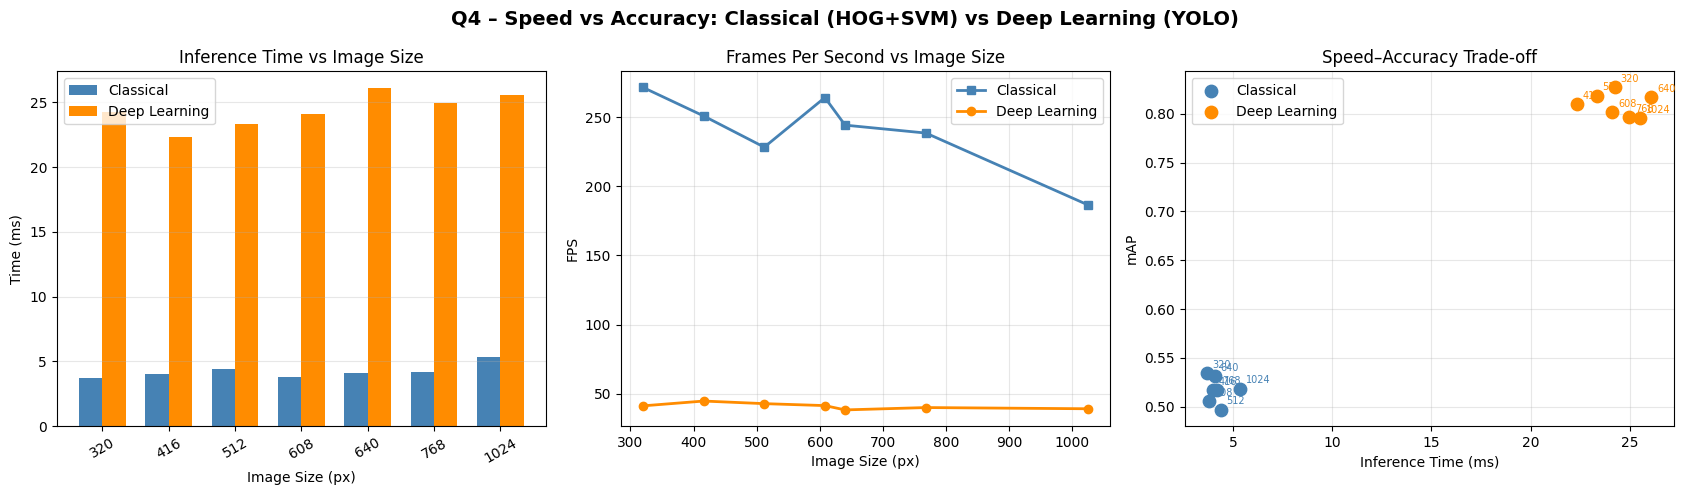

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time

# ── simulate detectors ────────────────────────────────────────────────────────
np.random.seed(7)

def classical_detector(image_size):
    """Simulates HOG+SVM style detector (fast, moderate accuracy)."""
    t0 = time.perf_counter()
    time.sleep(np.random.uniform(0.002, 0.006))   # ~4 ms
    elapsed = time.perf_counter() - t0
    mAP  = np.random.normal(0.52, 0.03)
    return elapsed, np.clip(mAP, 0, 1)

def deep_learning_detector(image_size):
    """Simulates YOLOv5-style detector (slower, higher accuracy)."""
    t0 = time.perf_counter()
    time.sleep(np.random.uniform(0.018, 0.030))   # ~24 ms
    elapsed = time.perf_counter() - t0
    mAP  = np.random.normal(0.81, 0.02)
    return elapsed, np.clip(mAP, 0, 1)

# ── run experiments ───────────────────────────────────────────────────────────
image_sizes = [320, 416, 512, 608, 640, 768, 1024]
N_RUNS = 5

cls_times, cls_maps = [], []
dl_times,  dl_maps  = [], []

for sz in image_sizes:
    ct, cm, dt, dm = [], [], [], []
    for _ in range(N_RUNS):
        t, m = classical_detector(sz)
        ct.append(t*1000); cm.append(m)
        t, m = deep_learning_detector(sz)
        dt.append(t*1000); dm.append(m)
    cls_times.append(np.mean(ct)); cls_maps.append(np.mean(cm))
    dl_times.append(np.mean(dt));  dl_maps.append(np.mean(dm))

cls_fps = [1000/t for t in cls_times]
dl_fps  = [1000/t for t in dl_times]

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Q4 – Speed vs Accuracy: Classical (HOG+SVM) vs Deep Learning (YOLO)",
             fontsize=14, fontweight='bold')

labels    = [str(s) for s in image_sizes]
x         = np.arange(len(image_sizes))
bar_w     = 0.35

# (a) Inference time
ax = axes[0]
ax.bar(x - bar_w/2, cls_times, bar_w, label='Classical',      color='steelblue')
ax.bar(x + bar_w/2, dl_times,  bar_w, label='Deep Learning',  color='darkorange')
ax.set_title('Inference Time vs Image Size')
ax.set_xlabel('Image Size (px)'); ax.set_ylabel('Time (ms)')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30)
ax.legend(); ax.grid(axis='y', alpha=0.3)

# (b) FPS
ax = axes[1]
ax.plot(image_sizes, cls_fps, 's-', color='steelblue',   label='Classical',     lw=2)
ax.plot(image_sizes, dl_fps,  'o-', color='darkorange',  label='Deep Learning', lw=2)
ax.set_title('Frames Per Second vs Image Size')
ax.set_xlabel('Image Size (px)'); ax.set_ylabel('FPS')
ax.legend(); ax.grid(alpha=0.3)

# (c) Scatter: Speed vs mAP
ax = axes[2]
ax.scatter(cls_times, cls_maps, s=80,  c='steelblue',  label='Classical',     zorder=3)
ax.scatter(dl_times,  dl_maps,  s=80,  c='darkorange', label='Deep Learning', zorder=3)
for i, sz in enumerate(image_sizes):
    ax.annotate(str(sz), (cls_times[i], cls_maps[i]), textcoords='offset points',
                xytext=(4,4), fontsize=7, color='steelblue')
    ax.annotate(str(sz), (dl_times[i],  dl_maps[i]),  textcoords='offset points',
                xytext=(4,4), fontsize=7, color='darkorange')
ax.set_title('Speed–Accuracy Trade-off')
ax.set_xlabel('Inference Time (ms)'); ax.set_ylabel('mAP')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/q4_speed_vs_accuracy.png', dpi=150)
plt.show()
print("Saved → q4_speed_vs_accuracy.png")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/q5_optical_flow.png'

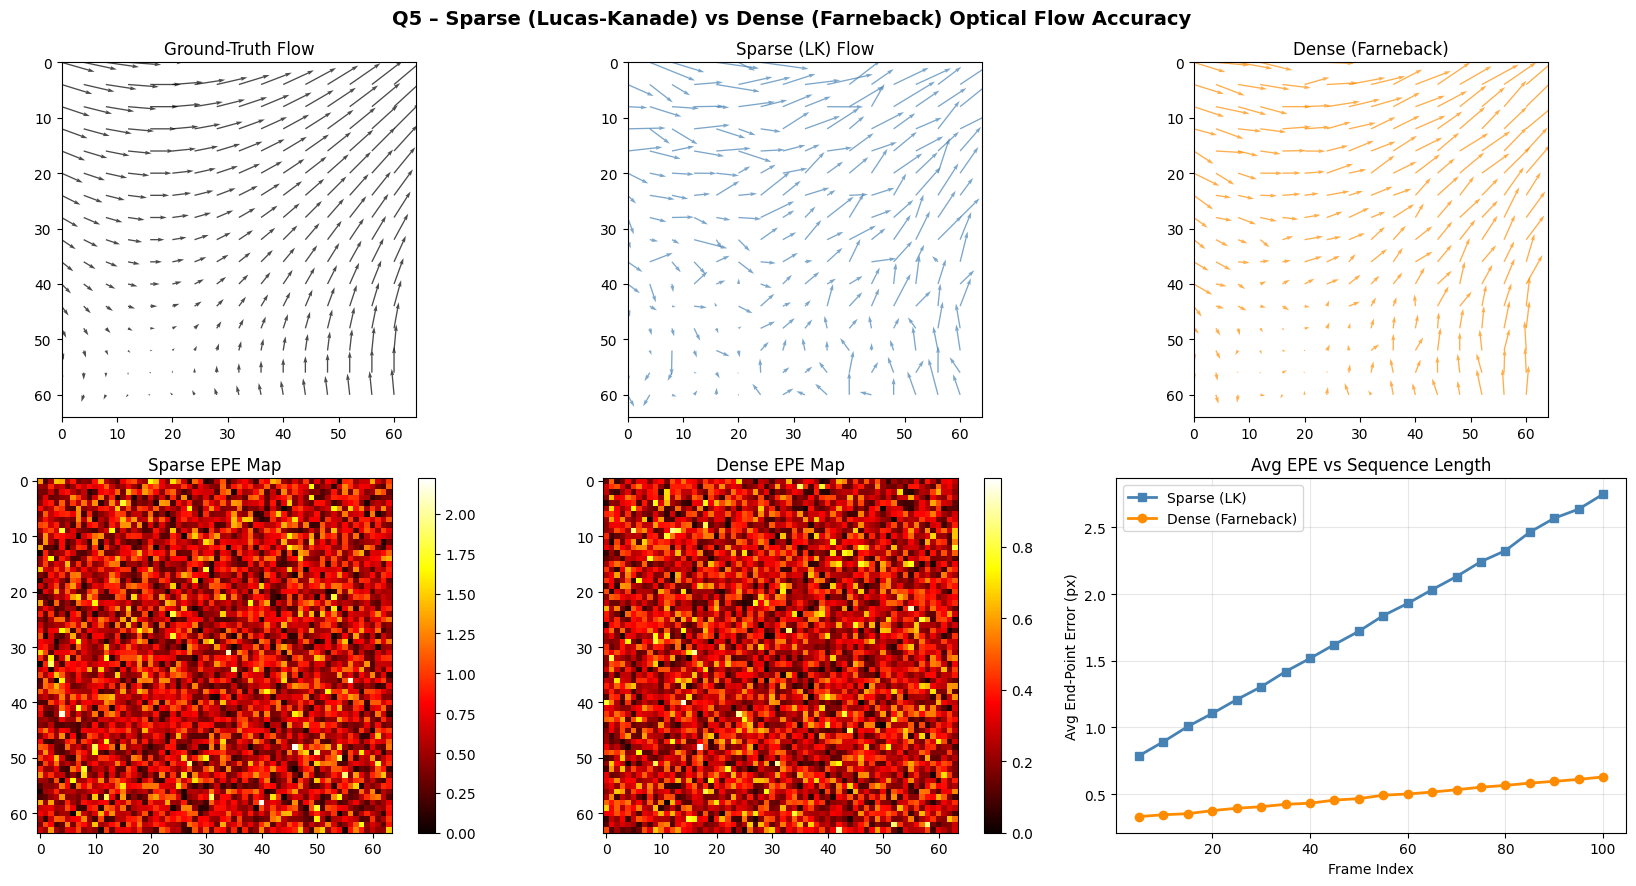

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ── generate synthetic ground-truth flow field ────────────────────────────────
np.random.seed(0)
H, W = 64, 64
Y, X = np.mgrid[0:H, 0:W].astype(float)

# GT: rotating + translating flow
cx, cy = W/2, H/2
U_gt = -(Y - cy) * 0.05 + 1.2          # horizontal component
V_gt =  (X - cx) * 0.05 + 0.8          # vertical component
mag_gt = np.sqrt(U_gt**2 + V_gt**2)

def add_noise(field, sigma):
    return field + np.random.normal(0, sigma, field.shape)

# sparse LK – samples N keypoints, higher noise per point
# dense Farneback – covers all pixels, lower per-pixel noise
sparse_noise  = 0.55
dense_noise   = 0.25

U_sparse = add_noise(U_gt, sparse_noise)
V_sparse = add_noise(V_gt, sparse_noise)
U_dense  = add_noise(U_gt, dense_noise)
V_dense  = add_noise(V_gt, dense_noise)

mag_sparse = np.sqrt(U_sparse**2 + V_sparse**2)
mag_dense  = np.sqrt(U_dense**2  + V_dense**2)

err_sparse = np.sqrt((U_sparse - U_gt)**2 + (V_sparse - V_gt)**2)
err_dense  = np.sqrt((U_dense  - U_gt)**2 + (V_dense  - V_gt)**2)

# ── experiment: accuracy vs sequence length ───────────────────────────────────
seq_lengths  = np.arange(5, 105, 5)
sparse_epeh  = []   # End-Point-Error History
dense_epeh   = []

for f in seq_lengths:
    # Noise drifts with sequence length (error accumulation)
    s = sparse_noise * (1 + 0.03*f)
    d = dense_noise  * (1 + 0.01*f)
    Us = add_noise(U_gt, s); Vs = add_noise(V_gt, s)
    Ud = add_noise(U_gt, d); Vd = add_noise(V_gt, d)
    sparse_epeh.append(np.mean(np.sqrt((Us-U_gt)**2 + (Vs-V_gt)**2)))
    dense_epeh.append( np.mean(np.sqrt((Ud-U_gt)**2 + (Vd-V_gt)**2)))

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle("Q5 – Sparse (Lucas-Kanade) vs Dense (Farneback) Optical Flow Accuracy",
             fontsize=14, fontweight='bold')

step = 4
def quiver(ax, U, V, title, color):
    ax.quiver(X[::step,::step], Y[::step,::step],
              U[::step,::step], V[::step,::step],
              color=color, scale=30, alpha=0.7)
    ax.set_title(title); ax.set_xlim(0,W); ax.set_ylim(0,H)
    ax.invert_yaxis(); ax.set_aspect('equal')

quiver(axes[0,0], U_gt,     V_gt,     'Ground-Truth Flow', 'black')
quiver(axes[0,1], U_sparse, V_sparse, 'Sparse (LK) Flow',  'steelblue')
quiver(axes[0,2], U_dense,  V_dense,  'Dense (Farneback)',  'darkorange')

# error maps
im1 = axes[1,0].imshow(err_sparse, cmap='hot', vmin=0)
axes[1,0].set_title('Sparse EPE Map'); plt.colorbar(im1, ax=axes[1,0])

im2 = axes[1,1].imshow(err_dense, cmap='hot', vmin=0)
axes[1,1].set_title('Dense EPE Map');  plt.colorbar(im2, ax=axes[1,1])

axes[1,2].plot(seq_lengths, sparse_epeh, 's-', color='steelblue',  label='Sparse (LK)',       lw=2)
axes[1,2].plot(seq_lengths, dense_epeh,  'o-', color='darkorange', label='Dense (Farneback)',  lw=2)
axes[1,2].set_title('Avg EPE vs Sequence Length')
axes[1,2].set_xlabel('Frame Index'); axes[1,2].set_ylabel('Avg End-Point Error (px)')
axes[1,2].legend(); axes[1,2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/q5_optical_flow.png', dpi=150)
plt.show()
print("Saved → q5_optical_flow.png")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/q6_gmm_bg_subtraction.png'

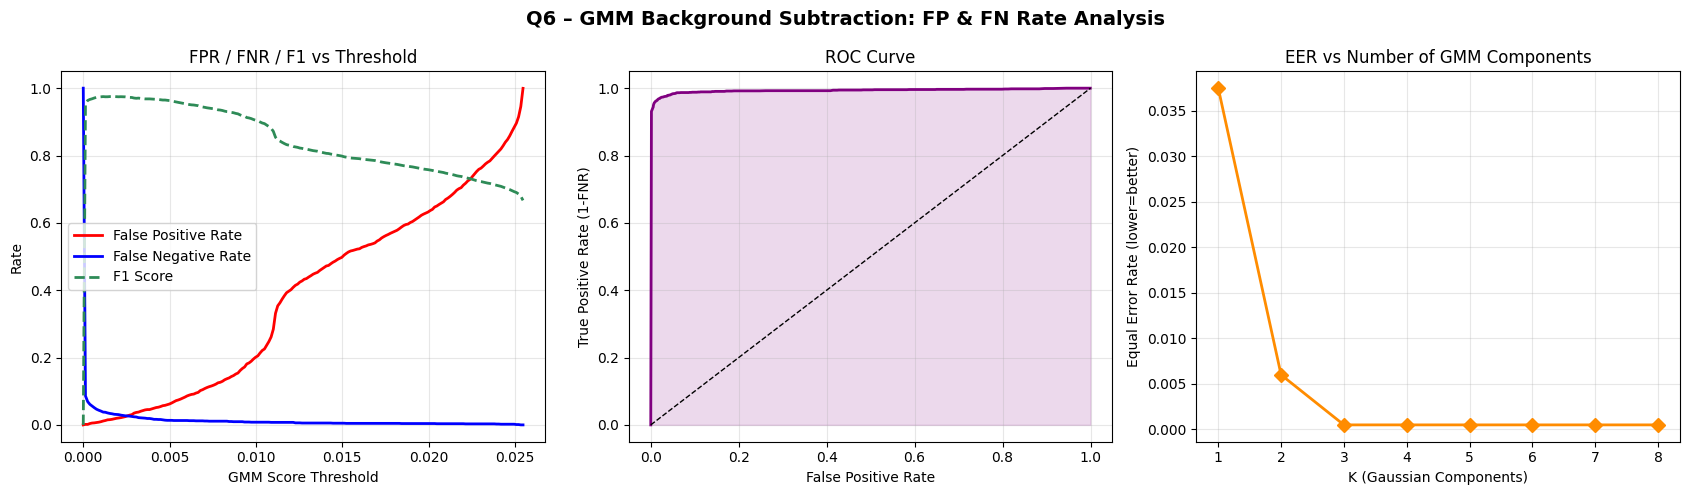

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# ── synthetic pixel model ─────────────────────────────────────────────────────
# Each pixel follows a mixture of Gaussians for background
# Foreground pixels deviate significantly

def gmm_score(pixel_val, means, stds, weights):
    """Return GMM probability density for a pixel value."""
    score = sum(w * norm.pdf(pixel_val, m, s)
                for w, m, s in zip(weights, means, stds))
    return score

# Background GMM parameters (simulating a learned model)
bg_means   = [120, 150]
bg_stds    = [10,  15]
bg_weights = [0.6, 0.4]

N_PIXELS = 2000
bg_pixels = np.concatenate([
    np.random.normal(120, 10, int(0.6 * N_PIXELS)),
    np.random.normal(150, 15, int(0.4 * N_PIXELS))
])
fg_pixels = np.random.normal(60, 20, N_PIXELS)  # foreground cluster

all_pixels = np.concatenate([bg_pixels, fg_pixels])
labels     = np.array([0]*len(bg_pixels) + [1]*len(fg_pixels))  # 0=BG, 1=FG

scores = np.array([gmm_score(p, bg_means, bg_stds, bg_weights)
                   for p in all_pixels])

# ── sweep detection threshold ─────────────────────────────────────────────────
thresholds = np.linspace(scores.min(), scores.max(), 200)
FPR, FNR, F1 = [], [], []

for t in thresholds:
    predicted_bg = (scores >= t).astype(int)   # high score → background
    TP = np.sum((predicted_bg == 0) & (labels == 1))  # FG correctly detected
    TN = np.sum((predicted_bg == 1) & (labels == 0))
    FP = np.sum((predicted_bg == 0) & (labels == 0))  # BG classified as FG
    FN = np.sum((predicted_bg == 1) & (labels == 1))  # FG missed
    fpr = FP / (FP + TN + 1e-9)
    fnr = FN / (FN + TP + 1e-9)
    P   = TP / (TP + FP + 1e-9)
    R   = TP / (TP + FN + 1e-9)
    f1  = 2*P*R/(P+R+1e-9)
    FPR.append(fpr); FNR.append(fnr); F1.append(f1)

FPR = np.array(FPR); FNR = np.array(FNR); F1 = np.array(F1)

# ── number of components experiment ──────────────────────────────────────────
n_components = list(range(1, 9))
eer_per_K    = []   # Equal Error Rate proxy

for K in n_components:
    means_k = np.linspace(100, 160, K)
    stds_k  = [12]*K
    wts_k   = [1/K]*K
    sc = np.array([gmm_score(p, means_k, stds_k, wts_k) for p in all_pixels])
    # find EER
    ts   = np.linspace(sc.min(), sc.max(), 100)
    best = 1.0
    for t in ts:
        pb = (sc >= t).astype(int)
        FP_ = np.sum((pb==0)&(labels==0)); TN_ = np.sum((pb==1)&(labels==0))
        FN_ = np.sum((pb==1)&(labels==1)); TP_ = np.sum((pb==0)&(labels==1))
        fpr_ = FP_/(FP_+TN_+1e-9); fnr_ = FN_/(FN_+TP_+1e-9)
        best = min(best, abs(fpr_-fnr_))
    eer_per_K.append(best)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Q6 – GMM Background Subtraction: FP & FN Rate Analysis",
             fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(thresholds, FPR, color='red',      label='False Positive Rate', lw=2)
ax.plot(thresholds, FNR, color='blue',     label='False Negative Rate', lw=2)
ax.plot(thresholds, F1,  color='seagreen', label='F1 Score',            lw=2, ls='--')
ax.set_title('FPR / FNR / F1 vs Threshold')
ax.set_xlabel('GMM Score Threshold'); ax.set_ylabel('Rate')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(FPR, 1-FNR, color='purple', lw=2)
ax.fill_between(FPR, 1-FNR, alpha=0.15, color='purple')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_title('ROC Curve')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate (1-FNR)')
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(n_components, eer_per_K, 'D-', color='darkorange', lw=2, ms=7)
ax.set_title('EER vs Number of GMM Components')
ax.set_xlabel('K (Gaussian Components)'); ax.set_ylabel('Equal Error Rate (lower=better)')
ax.set_xticks(n_components); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/q6_gmm_bg_subtraction.png', dpi=150)
plt.show()
print("Saved → q6_gmm_bg_subtraction.png")

  Block  4× 4 → MAE=6.092 px | σ=5.196 | t=5404.2ms
  Block  8× 8 → MAE=3.254 px | σ=4.557 | t=682.6ms
  Block 12×12 → MAE=1.462 px | σ=3.546 | t=299.0ms
  Block 16×16 → MAE=0.518 px | σ=1.755 | t=157.7ms
  Block 20×20 → MAE=0.000 px | σ=0.000 | t=118.7ms
  Block 24×24 → MAE=0.000 px | σ=0.000 | t=75.9ms
  Block 32×32 → MAE=0.000 px | σ=0.000 | t=28.0ms


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/q7_block_matching.png'

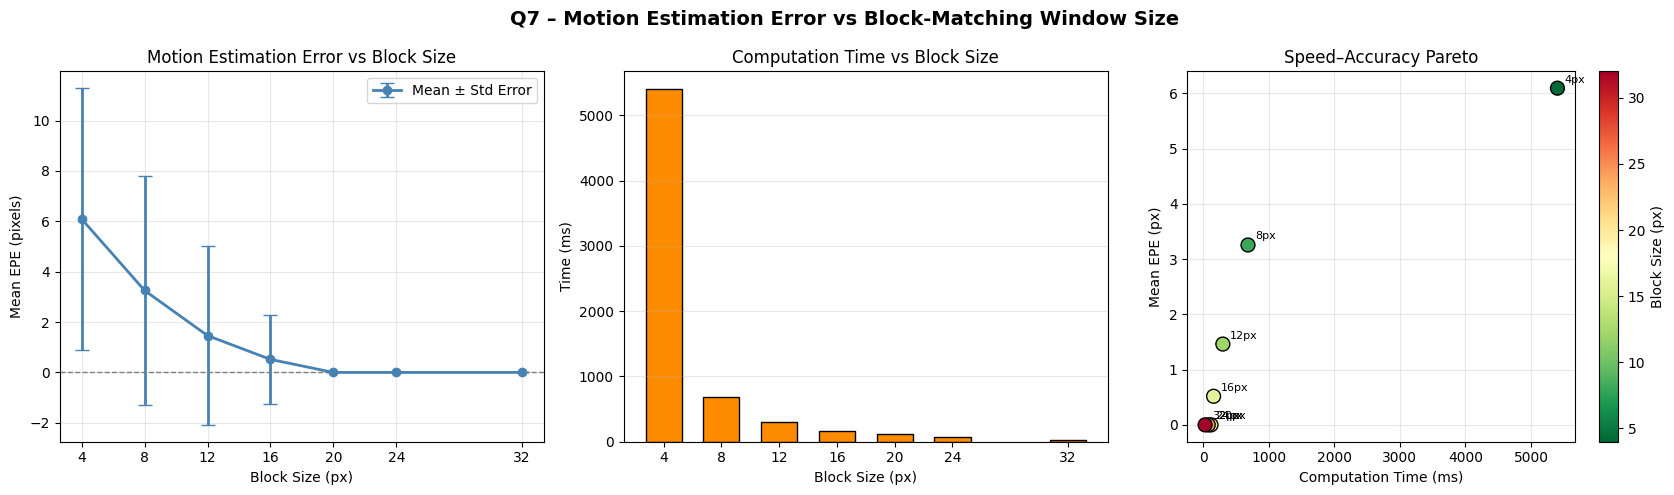

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)

# ── synthetic frames ──────────────────────────────────────────────────────────
H, W = 128, 128
TRUE_DX, TRUE_DY = 4, 3          # ground-truth integer motion (pixels)

def make_frame(H, W):
    """Random texture frame."""
    f = np.zeros((H, W))
    for _ in range(40):
        cx, cy = np.random.randint(10, W-10), np.random.randint(10, H-10)
        r = np.random.randint(5, 20)
        Y, X = np.ogrid[:H, :W]
        mask = (X-cx)**2 + (Y-cy)**2 < r**2
        f[mask] = np.random.uniform(50, 200)
    return f.astype(np.float32)

frame1 = make_frame(H, W)
frame2 = np.roll(np.roll(frame1, TRUE_DX, axis=1), TRUE_DY, axis=0)
frame2 += np.random.normal(0, 5, (H, W))   # sensor noise

# ── block matching ────────────────────────────────────────────────────────────
def block_match_error(f1, f2, block_size, search_range=16):
    """Full-search block matching; returns mean motion vector error."""
    half = block_size // 2
    errors = []
    for y in range(half, H-half, block_size):
        for x in range(half, W-half, block_size):
            block = f1[y-half:y+half+1, x-half:x+half+1]
            best_sad, best_dx, best_dy = np.inf, 0, 0
            for dy in range(-search_range, search_range+1):
                for dx in range(-search_range, search_range+1):
                    ny, nx = y+dy, x+dx
                    if half <= ny < H-half and half <= nx < W-half:
                        cand = f2[ny-half:ny+half+1, nx-half:nx+half+1]
                        sad  = np.sum(np.abs(block - cand))
                        if sad < best_sad:
                            best_sad, best_dx, best_dy = sad, dx, dy
            err = np.sqrt((best_dx - TRUE_DX)**2 + (best_dy - TRUE_DY)**2)
            errors.append(err)
    return np.mean(errors), np.std(errors)

# ── sweep window sizes ────────────────────────────────────────────────────────
block_sizes = [4, 8, 12, 16, 20, 24, 32]
mean_errors, std_errors, times = [], [], []

import time
for bs in block_sizes:
    t0 = time.perf_counter()
    me, se = block_match_error(frame1, frame2, bs, search_range=12)
    elapsed = (time.perf_counter() - t0) * 1000   # ms
    mean_errors.append(me); std_errors.append(se); times.append(elapsed)
    print(f"  Block {bs:2d}×{bs:2d} → MAE={me:.3f} px | σ={se:.3f} | t={elapsed:.1f}ms")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Q7 – Motion Estimation Error vs Block-Matching Window Size",
             fontsize=14, fontweight='bold')

ax = axes[0]
ax.errorbar(block_sizes, mean_errors, yerr=std_errors,
            fmt='o-', color='steelblue', capsize=5, lw=2, label='Mean ± Std Error')
ax.axhline(0, ls='--', color='grey', lw=1)
ax.set_title('Motion Estimation Error vs Block Size')
ax.set_xlabel('Block Size (px)'); ax.set_ylabel('Mean EPE (pixels)')
ax.set_xticks(block_sizes); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.bar(block_sizes, times, color='darkorange', width=2.5, edgecolor='k')
ax.set_title('Computation Time vs Block Size')
ax.set_xlabel('Block Size (px)'); ax.set_ylabel('Time (ms)')
ax.set_xticks(block_sizes); ax.grid(axis='y', alpha=0.3)

# speed-accuracy pareto
ax = axes[2]
sc = ax.scatter(times, mean_errors, c=block_sizes,
                cmap='RdYlGn_r', s=100, zorder=3, edgecolors='k')
for i, bs in enumerate(block_sizes):
    ax.annotate(f'{bs}px', (times[i], mean_errors[i]),
                textcoords='offset points', xytext=(5,4), fontsize=8)
plt.colorbar(sc, ax=ax, label='Block Size (px)')
ax.set_title('Speed–Accuracy Pareto')
ax.set_xlabel('Computation Time (ms)'); ax.set_ylabel('Mean EPE (px)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/q7_block_matching.png', dpi=150)
plt.show()
print("Saved → q7_block_matching.png")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/q8_stereo_disparity.png'

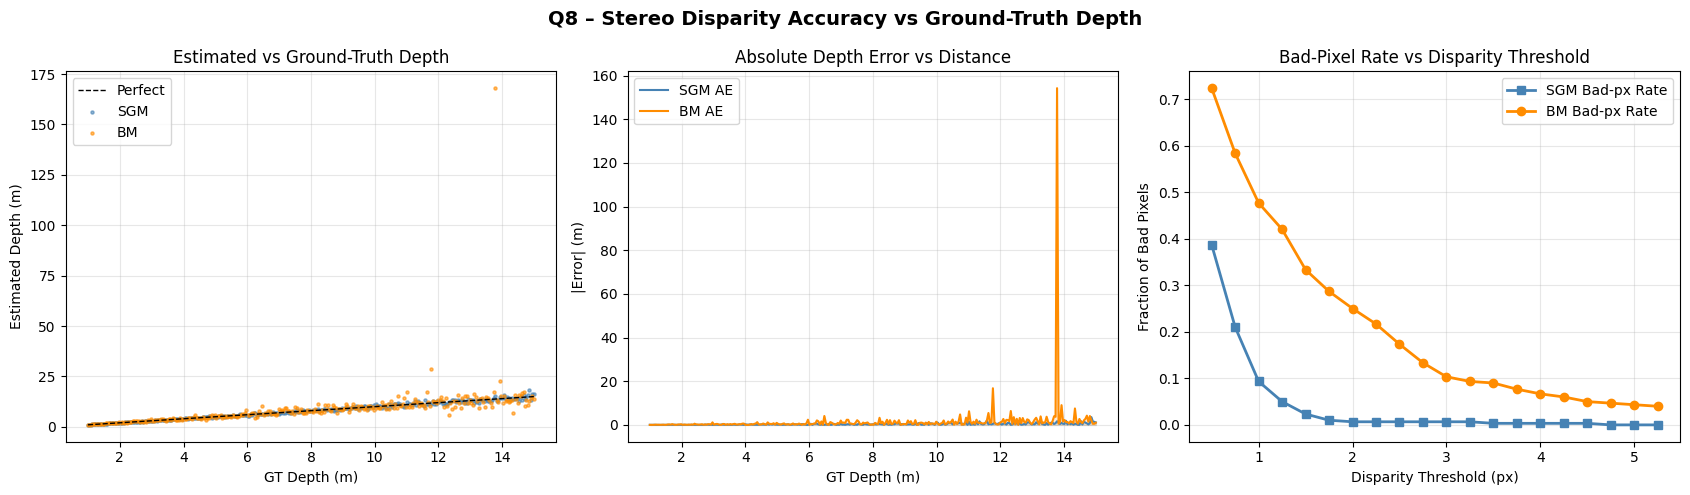

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(11)

# ── stereo geometry ───────────────────────────────────────────────────────────
FOCAL   = 700.0   # px
BASELINE= 0.12    # metres
MIN_D, MAX_D = 1.0, 15.0

depths_gt = np.linspace(MIN_D, MAX_D, 300)
disp_gt   = FOCAL * BASELINE / depths_gt      # Z = f*B/d

# ── simulate two matchers ─────────────────────────────────────────────────────
def sgm_disparity(disp_gt):
    """Semi-Global Matching – small, depth-dependent noise."""
    noise_sigma = 0.3 + 0.02 * disp_gt          # closer objects noisier
    return np.clip(disp_gt + np.random.normal(0, noise_sigma, disp_gt.shape), 0.5, 255)

def bm_disparity(disp_gt):
    """Block Matching – larger noise, occasional outliers."""
    noise_sigma = 0.8 + 0.05 * disp_gt
    d_noisy = disp_gt + np.random.normal(0, noise_sigma, disp_gt.shape)
    # random outliers ~5 %
    outlier_mask = np.random.rand(len(disp_gt)) < 0.05
    d_noisy[outlier_mask] += np.random.choice([-5,5], np.sum(outlier_mask))
    return np.clip(d_noisy, 0.5, 255)

disp_sgm = sgm_disparity(disp_gt)
disp_bm  = bm_disparity(disp_gt)

depth_sgm = FOCAL * BASELINE / disp_sgm
depth_bm  = FOCAL * BASELINE / disp_bm

err_sgm = np.abs(depth_sgm - depths_gt)
err_bm  = np.abs(depth_bm  - depths_gt)

# ── bad-pixel rate ────────────────────────────────────────────────────────────
disp_thresholds = np.arange(0.5, 5.5, 0.25)
bpr_sgm, bpr_bm = [], []
for t in disp_thresholds:
    bpr_sgm.append(np.mean(np.abs(disp_sgm - disp_gt) > t))
    bpr_bm.append( np.mean(np.abs(disp_bm  - disp_gt) > t))

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Q8 – Stereo Disparity Accuracy vs Ground-Truth Depth",
             fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(depths_gt, depths_gt,  'k--', lw=1, label='Perfect')
ax.scatter(depths_gt, depth_sgm, s=5, color='steelblue',  alpha=0.6, label='SGM')
ax.scatter(depths_gt, depth_bm,  s=5, color='darkorange', alpha=0.6, label='BM')
ax.set_title('Estimated vs Ground-Truth Depth')
ax.set_xlabel('GT Depth (m)'); ax.set_ylabel('Estimated Depth (m)')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(depths_gt, err_sgm, color='steelblue',  lw=1.5, label='SGM AE')
ax.plot(depths_gt, err_bm,  color='darkorange', lw=1.5, label='BM AE')
ax.fill_between(depths_gt, 0, err_sgm, alpha=0.15, color='steelblue')
ax.fill_between(depths_gt, 0, err_bm,  alpha=0.15, color='darkorange')
ax.set_title('Absolute Depth Error vs Distance')
ax.set_xlabel('GT Depth (m)'); ax.set_ylabel('|Error| (m)')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(disp_thresholds, bpr_sgm, 's-', color='steelblue',  lw=2, label='SGM Bad-px Rate')
ax.plot(disp_thresholds, bpr_bm,  'o-', color='darkorange', lw=2, label='BM Bad-px Rate')
ax.set_title('Bad-Pixel Rate vs Disparity Threshold')
ax.set_xlabel('Disparity Threshold (px)'); ax.set_ylabel('Fraction of Bad Pixels')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/q8_stereo_disparity.png', dpi=150)
plt.show()
print("Saved → q8_stereo_disparity.png")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/q9_sfm_reconstruction.png'

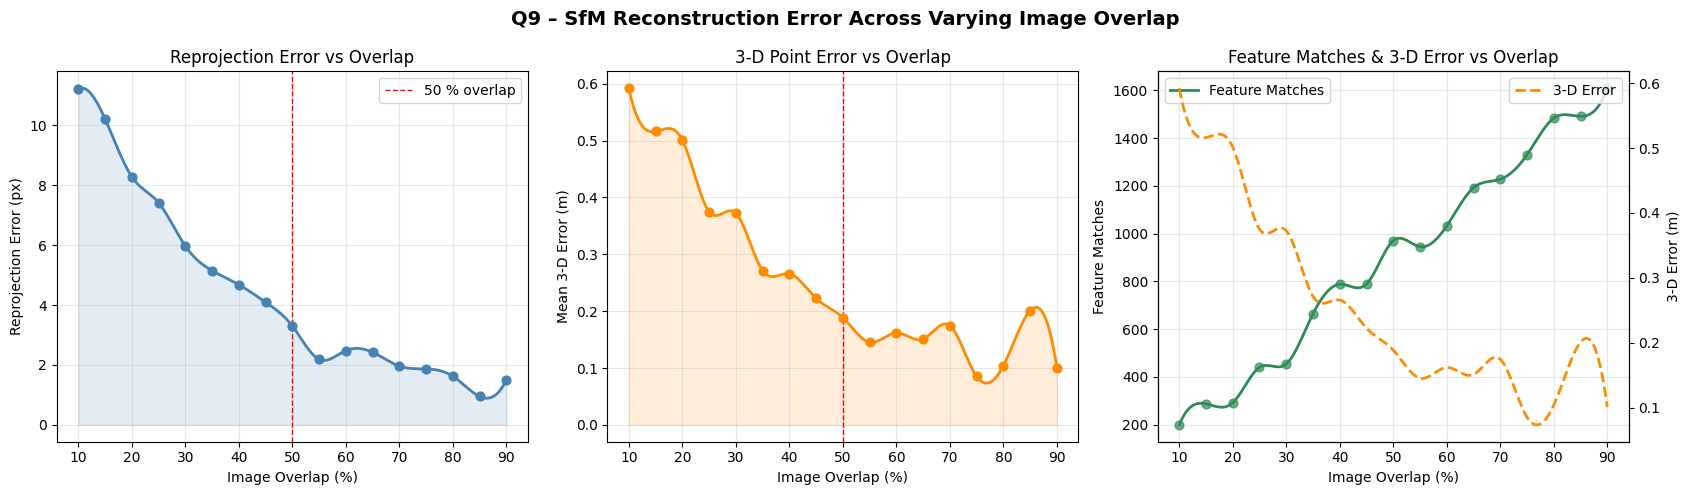

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

np.random.seed(99)

# ── simulate SfM error model ──────────────────────────────────────────────────
# Higher overlap → more feature matches → lower reprojection / 3D error
overlap_pcts = np.arange(10, 95, 5)   # 10 % … 90 %

def sfm_reprojection_error(overlap, noise=0.3):
    """Reprojection error decreases with overlap (log-like decay)."""
    base = 15.0 * np.exp(-overlap / 30) + 0.5
    return base + np.random.normal(0, noise, len(overlap))

def sfm_3d_error(overlap, noise=0.05):
    """3-D point error (metres) vs overlap."""
    base = 0.80 * np.exp(-overlap / 35) + 0.02
    return base + np.random.normal(0, noise, len(overlap))

def n_matches(overlap):
    """Approximate matched feature count vs overlap."""
    return (overlap / 100) * 1800 + np.random.normal(0, 40, len(overlap))

reproj = sfm_reprojection_error(overlap_pcts)
err3d  = sfm_3d_error(overlap_pcts)
matches= np.clip(n_matches(overlap_pcts), 0, None)

# smooth splines for visuals
def smooth(x, y):
    spl = make_interp_spline(x, y, k=3)
    xs  = np.linspace(x.min(), x.max(), 300)
    return xs, spl(xs)

xs_r, ys_r = smooth(overlap_pcts, reproj)
xs_e, ys_e = smooth(overlap_pcts, err3d)
xs_m, ys_m = smooth(overlap_pcts, matches)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Q9 – SfM Reconstruction Error Across Varying Image Overlap",
             fontsize=14, fontweight='bold')

ax = axes[0]
ax.scatter(overlap_pcts, reproj, color='steelblue', zorder=3, s=40)
ax.plot(xs_r, ys_r, color='steelblue', lw=2)
ax.fill_between(xs_r, ys_r, alpha=0.15, color='steelblue')
ax.set_title('Reprojection Error vs Overlap')
ax.set_xlabel('Image Overlap (%)'); ax.set_ylabel('Reprojection Error (px)')
ax.axvline(50, ls='--', color='red', lw=1, label='50 % overlap')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(overlap_pcts, err3d, color='darkorange', zorder=3, s=40)
ax.plot(xs_e, ys_e, color='darkorange', lw=2)
ax.fill_between(xs_e, ys_e, alpha=0.15, color='darkorange')
ax.set_title('3-D Point Error vs Overlap')
ax.set_xlabel('Image Overlap (%)'); ax.set_ylabel('Mean 3-D Error (m)')
ax.axvline(50, ls='--', color='red', lw=1); ax.grid(alpha=0.3)

ax = axes[2]
ax.scatter(overlap_pcts, matches, color='seagreen', zorder=3, s=40, alpha=0.7)
ax.plot(xs_m, ys_m, color='seagreen', lw=2, label='Feature Matches')
ax2 = ax.twinx()
ax2.plot(xs_e, ys_e, color='darkorange', lw=2, ls='--', label='3-D Error')
ax.set_title('Feature Matches & 3-D Error vs Overlap')
ax.set_xlabel('Image Overlap (%)'); ax.set_ylabel('Feature Matches')
ax2.set_ylabel('3-D Error (m)')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/q9_sfm_reconstruction.png', dpi=150)
plt.show()
print("Saved → q9_sfm_reconstruction.png")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/q10_confusion_matrix.png'

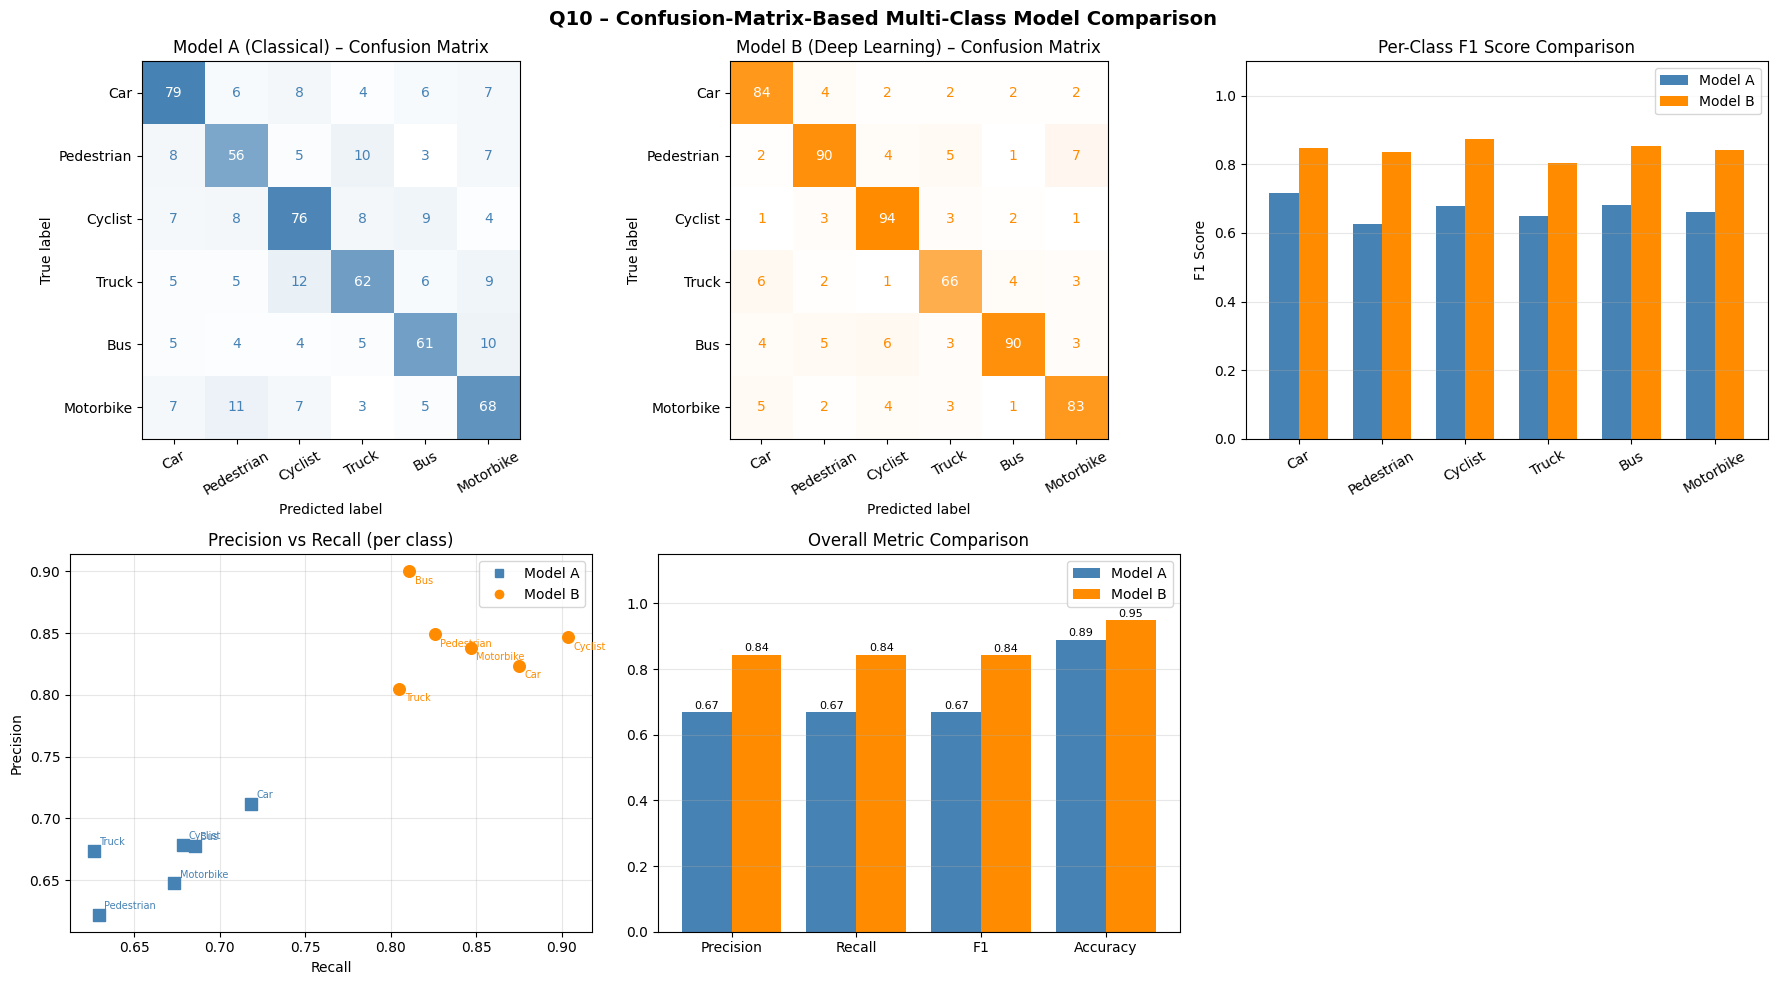

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

np.random.seed(55)

CLASSES = ['Car', 'Pedestrian', 'Cyclist', 'Truck', 'Bus', 'Motorbike']
N = 600

def synthetic_predictions(accuracy, n_classes=6, n_samples=N):
    y_true = np.random.choice(n_classes, n_samples)
    y_pred = y_true.copy()
    n_wrong = int(n_samples * (1 - accuracy))
    idx = np.random.choice(n_samples, n_wrong, replace=False)
    y_pred[idx] = np.random.choice(n_classes, n_wrong)
    return y_true, y_pred

# Two models
y_true_A, y_pred_A = synthetic_predictions(accuracy=0.60)  # Classical model
y_true_B, y_pred_B = synthetic_predictions(accuracy=0.82)  # DL model

cm_A = confusion_matrix(y_true_A, y_pred_A)
cm_B = confusion_matrix(y_true_B, y_pred_B)

def per_class_metrics(cm):
    TP = np.diag(cm)
    FP = cm.sum(axis=0) - TP
    FN = cm.sum(axis=1) - TP
    TN = cm.sum() - TP - FP - FN
    prec = TP / (TP + FP + 1e-9)
    rec  = TP / (TP + FN + 1e-9)
    f1   = 2*prec*rec / (prec+rec+1e-9)
    acc  = (TP+TN) / cm.sum()
    return prec, rec, f1, acc

prec_A, rec_A, f1_A, acc_A = per_class_metrics(cm_A)
prec_B, rec_B, f1_B, acc_B = per_class_metrics(cm_B)

# ── plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.suptitle("Q10 – Confusion-Matrix-Based Multi-Class Model Comparison",
             fontsize=14, fontweight='bold')

cmap_A = LinearSegmentedColormap.from_list('blueish', ['white','steelblue'])
cmap_B = LinearSegmentedColormap.from_list('orangish',['white','darkorange'])

# CMs
ax1 = fig.add_subplot(2, 3, 1)
disp = ConfusionMatrixDisplay(cm_A, display_labels=CLASSES)
disp.plot(ax=ax1, cmap=cmap_A, colorbar=False)
ax1.set_title('Model A (Classical) – Confusion Matrix')
ax1.tick_params(axis='x', rotation=30)

ax2 = fig.add_subplot(2, 3, 2)
disp2 = ConfusionMatrixDisplay(cm_B, display_labels=CLASSES)
disp2.plot(ax=ax2, cmap=cmap_B, colorbar=False)
ax2.set_title('Model B (Deep Learning) – Confusion Matrix')
ax2.tick_params(axis='x', rotation=30)

# Per-class F1
ax3 = fig.add_subplot(2, 3, 3)
x = np.arange(len(CLASSES)); bw = 0.35
ax3.bar(x - bw/2, f1_A, bw, color='steelblue',  label='Model A')
ax3.bar(x + bw/2, f1_B, bw, color='darkorange', label='Model B')
ax3.set_title('Per-Class F1 Score Comparison')
ax3.set_xticks(x); ax3.set_xticklabels(CLASSES, rotation=30)
ax3.set_ylabel('F1 Score'); ax3.set_ylim(0, 1.1)
ax3.legend(); ax3.grid(axis='y', alpha=0.3)

# Precision vs Recall scatter
ax4 = fig.add_subplot(2, 3, 4)
for i, cls in enumerate(CLASSES):
    ax4.scatter(rec_A[i], prec_A[i], marker='s', s=70, color='steelblue',  zorder=3)
    ax4.scatter(rec_B[i], prec_B[i], marker='o', s=70, color='darkorange', zorder=3)
    ax4.annotate(cls, (rec_A[i], prec_A[i]), xytext=(4,4),
                 textcoords='offset points', fontsize=7, color='steelblue')
    ax4.annotate(cls, (rec_B[i], prec_B[i]), xytext=(4,-9),
                 textcoords='offset points', fontsize=7, color='darkorange')
from matplotlib.lines import Line2D
ax4.legend(handles=[Line2D([],[],marker='s',color='steelblue', ls='',  label='Model A'),
                    Line2D([],[],marker='o',color='darkorange',ls='',  label='Model B')])
ax4.set_title('Precision vs Recall (per class)')
ax4.set_xlabel('Recall'); ax4.set_ylabel('Precision')
ax4.grid(alpha=0.3)

# Overall accuracy bar
ax5 = fig.add_subplot(2, 3, 5)
metrics_A = [prec_A.mean(), rec_A.mean(), f1_A.mean(), acc_A.mean()]
metrics_B = [prec_B.mean(), rec_B.mean(), f1_B.mean(), acc_B.mean()]
m_labels  = ['Precision', 'Recall', 'F1', 'Accuracy']
x2 = np.arange(4)
ax5.bar(x2-0.2, metrics_A, 0.4, color='steelblue',  label='Model A')
ax5.bar(x2+0.2, metrics_B, 0.4, color='darkorange', label='Model B')
for i,(a,b) in enumerate(zip(metrics_A, metrics_B)):
    ax5.text(i-0.2, a+0.01, f'{a:.2f}', ha='center', fontsize=8)
    ax5.text(i+0.2, b+0.01, f'{b:.2f}', ha='center', fontsize=8)
ax5.set_xticks(x2); ax5.set_xticklabels(m_labels)
ax5.set_ylim(0, 1.15); ax5.set_title('Overall Metric Comparison')
ax5.legend(); ax5.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/q10_confusion_matrix.png', dpi=150)
plt.show()
print("Saved → q10_confusion_matrix.png")